In [193]:
import pandas as pd
import numpy as np

# Настройки для воспроизводимости
np.random.seed(42)
n_samples = 5000
n_tickers = 4

# 1. Базовые данные
dates = pd.date_range(start='2020-01-01', periods=n_samples, freq='D')
tickers = ['AAPL', 'GOOGL', 'TSLA', 'MSFT']
sectors = ['Tech', 'Tech', 'Auto-Tech', 'Tech']

data = []
for idx, ticker in enumerate(tickers):
    ticker_samples = n_samples // n_tickers
    # Генерируем базовый случайный walk для цены закрытия
    close = 100 + np.cumsum(np.random.randn(ticker_samples) * 0.5)
    open_price = close + np.random.randn(ticker_samples) * 0.1
    high = np.maximum(open_price, close) + np.abs(np.random.randn(ticker_samples) * 0.2)
    low = np.minimum(open_price, close) - np.abs(np.random.randn(ticker_samples) * 0.2)
    volume = np.random.lognormal(mean=10, sigma=1.5, size=ticker_samples).astype(int)

    for i in range(ticker_samples):
        data.append([
            dates[i + idx*ticker_samples],
            ticker,
            sectors[idx],
            open_price[i],
            high[i],
            low[i],
            close[i],
            volume[i]
        ])

df = pd.DataFrame(data, columns=['date', 'ticker', 'sector', 'open', 'high', 'low', 'close', 'volume'])
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

# 2. Технические индикаторы
def calculate_indicators(group):
    group = group.copy()
    close = group['close']
    
    group['sma_20'] = close.rolling(window=20, min_periods=1).mean()
    
    delta = close.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    group['rsi_14'] = 100 - (100 / (1 + rs))
    
    rolling_std = close.rolling(window=20).std()
    group['bb_high'] = group['sma_20'] + (rolling_std * 2)
    group['bb_low'] = group['sma_20'] - (rolling_std * 2)
    
    tr1 = group['high'] - group['low']
    tr2 = abs(group['high'] - group['close'].shift())
    tr3 = abs(group['low'] - group['close'].shift())
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    group['atr_14'] = tr.rolling(window=14).mean()
    
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    group['macd'] = ema12 - ema26
    
    group['daily_return'] = close.pct_change() * 100
    group['gap'] = group['open'] - group['close'].shift(1)
    
    return group

df = df.groupby('ticker', group_keys=False).apply(calculate_indicators)

# 3. Категориальные признаки
market_trends = ['Bullish', 'Bearish', 'Sideways']
news_sentiments = ['Positive', 'Neutral', 'Negative']

def generate_correlated_categorical(n, categories, persistence=0.8):
    series = [np.random.choice(categories)]
    for _ in range(1, n):
        if np.random.random() < persistence:
            series.append(series[-1])
        else:
            series.append(np.random.choice(categories))
    return series

df['market_trend'] = generate_correlated_categorical(len(df), market_trends)
df['news_sentiment'] = generate_correlated_categorical(len(df), news_sentiments)

# 4. БИНАРНАЯ целевая переменная
future_return = df.groupby('ticker')['close'].pct_change().shift(-1)
# BUY если рост > 0.5%, иначе HOLD/SELL
df['target'] = (future_return > 0.005).astype(int)

# 5. Проблемные данные
outlier_indices = np.random.choice(df.index, size=int(0.01 * len(df)), replace=False)
df.loc[outlier_indices, 'volume'] = df.loc[outlier_indices, 'volume'] * 10

df['noise_feature'] = np.random.randn(len(df))
df['volatility_category'] = pd.qcut(df['atr_14'], q=3, labels=['Low', 'Medium', 'High'])

# 6. Финализация
df = df.dropna().reset_index(drop=True)
df.drop('date', axis=1, inplace=True)



C:\Users\user\AppData\Local\Temp\ipykernel_8340\4026809555.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('ticker', group_keys=False).apply(calculate_indicators)


In [194]:
df

,ticker,sector,open,high,low,close,volume,sma_20,rsi_14,bb_high,bb_low,atr_14,macd,daily_return,gap,market_trend,news_sentiment,target,noise_feature,volatility_category
0,AAPL,Tech,98.410624,98.580905,98.176430,98.287014,40023,100.755947,27.835719,103.115016,98.396877,0.683370,-0.394541,-0.713334,-0.582543,Bullish,Negative,1,1.400805,High
1,AAPL,Tech,99.128970,99.164012,98.819474,99.019839,20193,100.694521,27.167488,103.170328,98.218713,0.635535,-0.443643,0.745596,0.841955,Bullish,Negative,0,-1.714373,Medium
2,AAPL,Tech,98.967864,99.564916,98.807436,98.906951,7312,100.630907,21.876110,103.225016,98.036798,0.639694,-0.486063,-0.114006,-0.051974,Sideways,Negative,0,0.582620,Medium
3,AAPL,Tech,98.831483,99.014211,98.675083,98.940715,16665,100.552789,23.249354,103.254953,97.850626,0.635619,-0.511066,0.034137,-0.075467,Sideways,Neutral,0,0.447505,Medium
4,AAPL,Tech,98.196700,98.291047,98.044759,98.228341,2000,100.400977,17.122326,103.270728,97.531226,0.661346,-0.581658,-0.720001,-0.744015,Sideways,Neutral,0,0.531838,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4919,TSLA,Auto-Tech,120.527656,120.789024,120.429038,120.618621,7910,122.028939,41.177802,123.753033,120.304845,0.698650,0.055203,-0.246708,-0.389277,Sideways,Neutral,0,-1.632542,High
4920,TSLA,Auto-Tech,119.553551,119.866343,119.313999,119.429836,34367,121.945826,27.261090,123.990530,119.901123,0.723586,-0.134561,-0.985573,-1.065070,Sideways,Neutral,0,-0.803219,High
4921,TSLA,Auto-Tech,119.911168,120.077215,119.615379,119.779947,41766,121.870465,34.030493,124.118387,119.622543,0.715488,-0.253774,0.293152,0.481332,Sideways,Neutral,1,0.268508,High
4922,TSLA,Auto-Tech,120.801697,120.982558,120.758564,120.890108,62498,121.843562,39.675981,124.126380,119.560744,0.747648,-0.255723,0.926834,1.021750,Sideways,Positive,0,-0.724400,High


# Пропуски и выбросы

In [195]:
df.isna().sum()

ticker                 0
sector                 0
open                   0
high                   0
low                    0
close                  0
volume                 0
sma_20                 0
rsi_14                 0
bb_high                0
bb_low                 0
atr_14                 0
macd                   0
daily_return           0
gap                    0
market_trend           0
news_sentiment         0
target                 0
noise_feature          0
volatility_category    0
dtype: int64

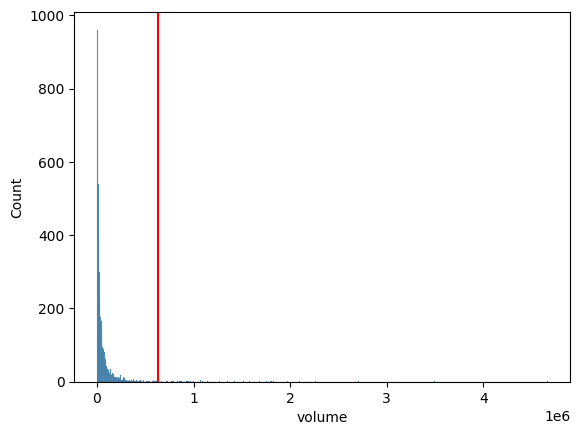

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns
mean_ = np.mean(df['volume'])
std_ = np.std(df['volume'])
sns.histplot(df['volume'])
plt.axvline(mean_ + std_ * 3, color='red')

In [197]:
df = df[~(df['volume'] > mean_ + 3 * std_)]

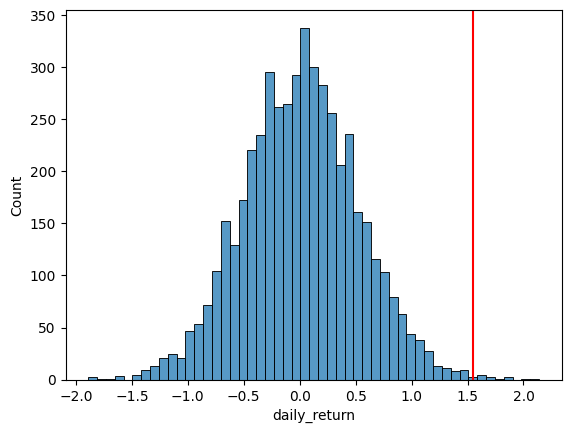

In [198]:
mean_ = np.mean(df['daily_return'])
std_ = np.std(df['daily_return'])
sns.histplot(df['daily_return'])
plt.axvline(mean_ + std_ * 3, color='red')
mask1 = df['daily_return'] > mean_ + 3 * std_
mask2 = df['daily_return'] < mean_ - 3 * std_
df = df[~(mask1 | mask2)]

# Основные 4 модели классификации с пайплайном + кросс-валидация + roc-auc

In [199]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc

In [200]:
X, y = df.drop('target', axis=1), df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7)

In [201]:
categorical_features = ['ticker','sector', 'market_trend','news_sentiment','volatility_category']
numerical_features = ['open','high','low','close','volume','sma_20','rsi_14','bb_high','bb_low','atr_14','macd','daily_return','gap','noise_feature']
Pipeline_log = Pipeline([('preprocessor', ColumnTransformer([('num', StandardScaler(), numerical_features),
                                                             ('cat', OneHotEncoder(), categorical_features)])),
                          ('model', LogisticRegression(random_state=42))])
kf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
score = cross_val_score(Pipeline_log, X, y, scoring='accuracy')
print(score)      

[0.83557394 0.83557394 0.83660807 0.83660807 0.83660807]


In [202]:
from sklearn import metrics
Pipeline_log.fit(X_train, y_train)
y_pred_log = Pipeline_log.predict(X_test)
print(metrics.classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

           0       0.83      1.00      0.90      1199
           1       0.00      0.00      0.00       252

    accuracy                           0.83      1451
   macro avg       0.41      0.50      0.45      1451
weighted avg       0.68      0.83      0.75      1451



c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


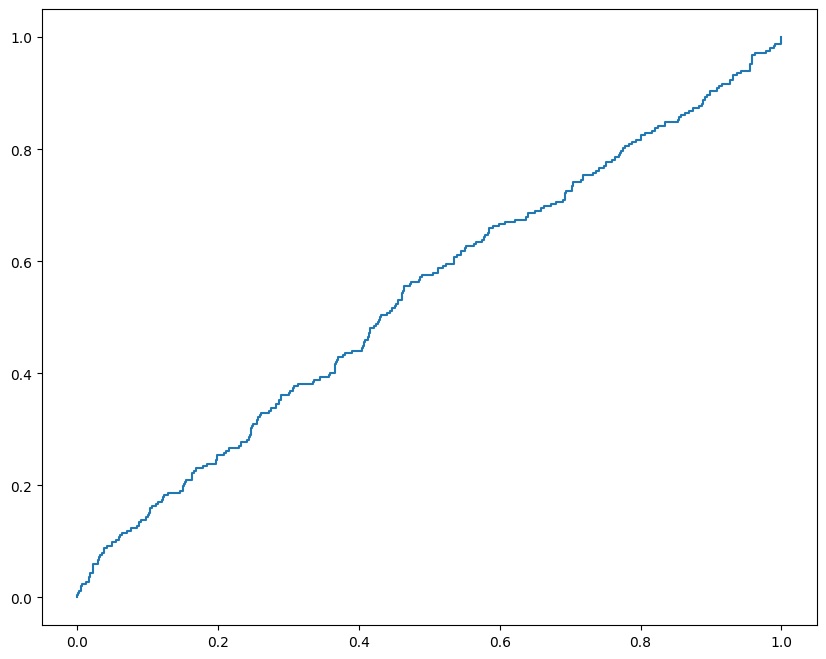

In [203]:
y_pred_proba_log = Pipeline_log.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_log)
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr);



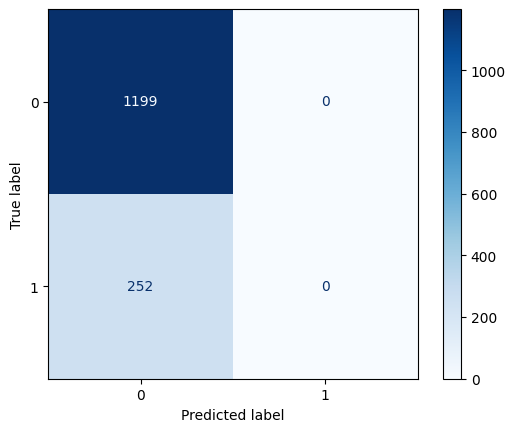

In [204]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, cmap=plt.cm.Blues,)

In [205]:
from sklearn.tree import DecisionTreeClassifier
Pipeline_Tree = Pipeline([('preprocessor', ColumnTransformer([('num', StandardScaler(), numerical_features),
                                                              ('cat', OneHotEncoder(), categorical_features)])),
                           ('model', DecisionTreeClassifier(random_state=42))])

In [206]:
Pipeline_Tree.fit(X_train, y_train)
y_pred_tree = Pipeline_Tree.predict(X_test)
print(metrics.classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1199
           1       0.17      0.17      0.17       252

    accuracy                           0.72      1451
   macro avg       0.50      0.50      0.50      1451
weighted avg       0.71      0.72      0.71      1451



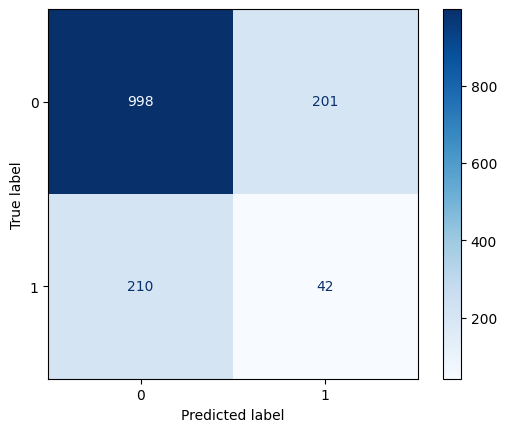

In [207]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, cmap=plt.cm.Blues)

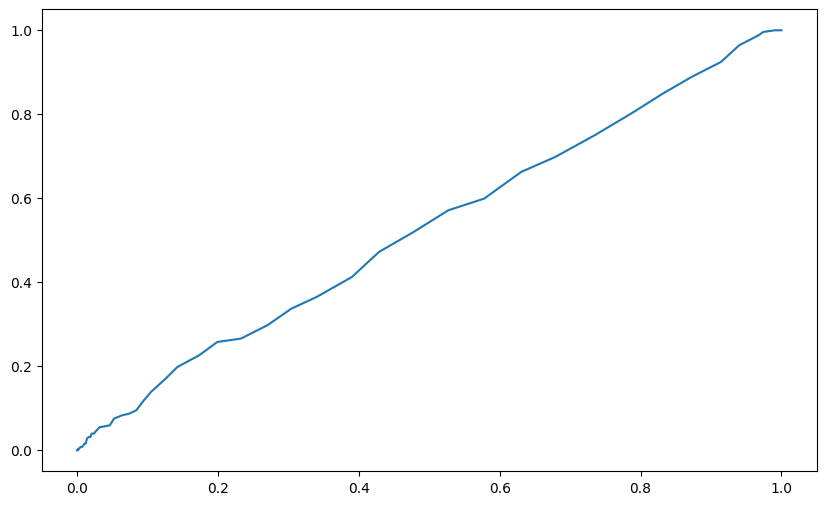

In [208]:
y_pred_tree_prob = Pipeline_Forest.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_tree_prob)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr)

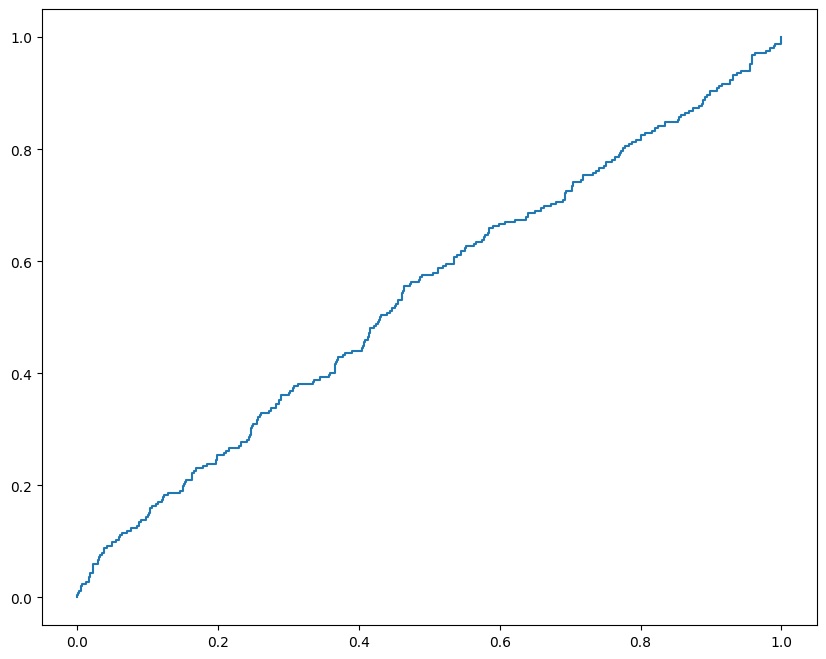

In [209]:
y_pred_proba_log = Pipeline_log.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_log)
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr);



In [210]:
from sklearn.ensemble import RandomForestClassifier
Pipeline_Forest = Pipeline([('preprocessor', ColumnTransformer([('num', StandardScaler(), numerical_features),
                                                              ('cat', OneHotEncoder(), categorical_features)])),
                           ('model', RandomForestClassifier(random_state=42))])
Pipeline_Forest.fit(X_train, y_train)
y_pred_forest = Pipeline_Forest.predict(X_test)
print(metrics.classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.83      0.99      0.90      1199
           1       0.25      0.01      0.02       252

    accuracy                           0.82      1451
   macro avg       0.54      0.50      0.46      1451
weighted avg       0.73      0.82      0.75      1451



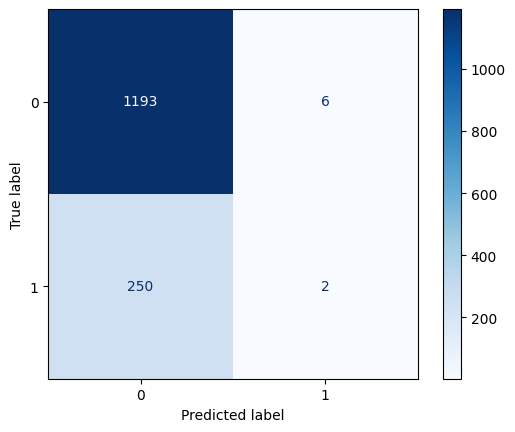

In [211]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_forest, cmap=plt.cm.Blues)

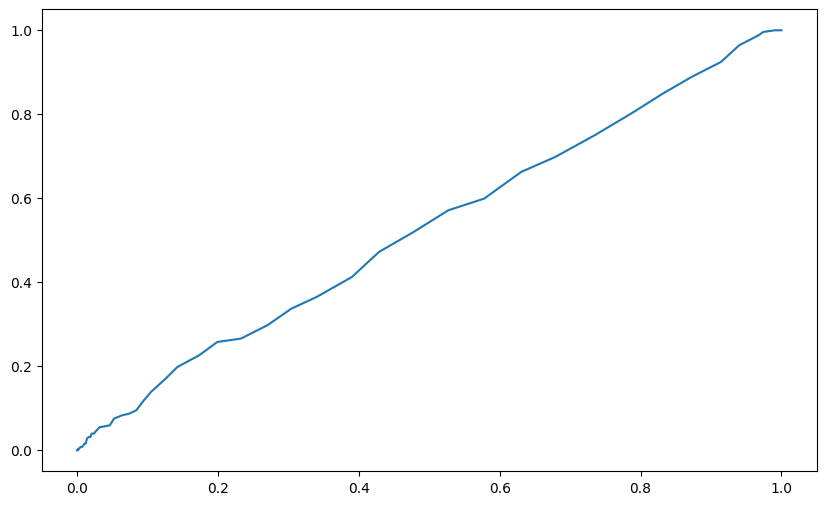

In [212]:
y_pred_tree_prob = Pipeline_Forest.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_tree_prob)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr)

In [213]:
from xgboost import XGBClassifier
Pipeline_XGBClassifier = Pipeline([('preprocessor', ColumnTransformer([('num', StandardScaler(), numerical_features),
                                                              ('cat', OneHotEncoder(), categorical_features)])),
                           ('model', XGBClassifier(random_state=42))])
Pipeline_XGBClassifier.fit(X_train, y_train)
y_pred_XGBClassifier = Pipeline_XGBClassifier.predict(X_test)
print(metrics.classification_report(y_test, y_pred_XGBClassifier))

              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1199
           1       0.19      0.03      0.05       252

    accuracy                           0.81      1451
   macro avg       0.51      0.50      0.47      1451
weighted avg       0.72      0.81      0.75      1451



# Добавим кросс-валидацию и 